<a href="https://colab.research.google.com/github/babi00/ai4biological-pattern/blob/clean-barbara/barbara_new/classificatore_specie_invasive_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Classificatore specie:
- input: immagine
- output label: nativa/non nativa e non invasiva/non nativa e invasiva
Pipeline modificata rispetto alla precedente versione: per poter utilizzare successivamente XAI (al livello di immagini) viene incorporato il passaggio di encoding di immagini.

Al momento viene utilizzato una dummy function per stabilire la label dell'immagine a partire da nome della specie e coordinate della foto. DA MODIFICARE

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, multilabel_confusion_matrix, confusion_matrix, ConfusionMatrixDisplay, f1_score
import seaborn as sns
import requests
from io import BytesIO
from google.colab import drive
import time
from tqdm import tqdm
!pip install open_clip_torch
import open_clip
import random

torch.manual_seed(42)
np.random.seed(42)

drive.mount('/content/drive')

# Clone the repository and checkout the 'clean-barbara' branch
!git clone --branch clean-barbara https://github.com/babi00/ai4biological-pattern.git
%cd ai4biological-pattern

# Enable sparse checkout
!git sparse-checkout init --cone

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
fatal: destination path 'ai4biological-pattern' already exists and is not an empty directory.
/content/ai4biological-pattern


In [2]:
class InvasiveSpeciesDataset(Dataset):
    def __init__(self, root_dir, specie_status, transform=None, get_label_fn=None):
        self.root_dir = root_dir
        self.transform = transform
        self.get_label_fn = get_label_fn
        self.image_info = []
        self.specie_status = specie_status

        taxa_folders = [d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d)) and d != "metadata"]
        for taxon in taxa_folders:
            meta_path = os.path.join(root_dir, "metadata", f"{taxon}_metadata.csv")
            if not os.path.exists(meta_path):
                continue
            metadata_df = pd.read_csv(meta_path)
            for _, row in metadata_df.iterrows():
                image_path = os.path.join(root_dir, taxon, str(row["filename"]))
                if os.path.exists(image_path):
                    label = self.get_label_fn(taxon, row["latitude"], row["longitude"])
                    self.image_info.append((image_path, label))

    def __len__(self):
        return len(self.image_info)

    def __getitem__(self, idx):
        image_path, label = self.image_info[idx]
        image = Image.open(image_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        obs_id = idx
        return image, label, obs_id

In [3]:
# Dummy version, replace this
def dummy_get_species_status(species_name, latitude, longitude):
    return random.choice([0, 1, 2])  # 0=native, 1=non-native non-invasive, 2=non-native invasive

In [4]:
def get_data_loader(root_dir, specie_status, batch_size=32, use_bioclip=True, preprocess=None):
    if use_bioclip and preprocess:
        transform = preprocess
    else:
        transform = transforms.Compose([
          transforms.Resize((224, 224)),
          transforms.ToTensor()
        ])

    dataset = InvasiveSpeciesDataset(
        root_dir=root_dir,
        specie_status=specie_status,
        transform=transform,
        get_label_fn=dummy_get_species_status
    )

    train_data, val_data = train_test_split(dataset, test_size=0.2, random_state=42)

    train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_data, batch_size=32, shuffle=False)

    return train_loader, val_loader

In [5]:
#2.Define the model
#ResNet model and replace just the last layer with the classification head
def get_resnet_model(num_classes, device, hidden_dim=256):
    #Use a pre-trained ResNet18 model
    model = models.resnet18(weights='IMAGENET1K_V1')

    #Freeze all layers
    for param in model.parameters():
        param.requires_grad = False

    #Replace the final fully connected layer
    in_ftrs = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(in_ftrs, hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, num_classes)
    )
    #Ensure the new fc layer's parameters are trainable
    for param in model.fc.parameters():
        param.requires_grad = True
    return model.to(device)

#BioCLIP models (v1 and v2): take the encode_image of BioCLIP and add the classification head
def get_bioclip_model(num_classes, device, bioclip_version=None, hidden_dim=256):
    if bioclip_version==2:
        print("BioCLIP 2!")
        model, _, preprocess = open_clip.create_model_and_transforms('hf-hub:imageomics/bioclip-2')
    else:
        model, _, preprocess = open_clip.create_model_and_transforms('hf-hub:imageomics/bioclip')
    model.to(device)

    #freeze all parameters
    for param in model.parameters():
        param.requires_grad = False

    #feed a fake image to get the output shape of the embedding
    dummy_input = torch.randn(1, 3, 224, 224).to(device)
    with torch.no_grad():
        embedding = model.encode_image(dummy_input)
    feature_dim = embedding.shape[-1]

    #classification head
    classification_head = nn.Sequential(
        nn.Linear(feature_dim, hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, num_classes)
    )

    #wrapper model that uses encode_image
    class BioCLIPClassifier(nn.Module):
        def __init__(self, clip_model, head):
            super().__init__()
            self.clip_model = clip_model
            self.head = head

        def forward(self, x):
            with torch.no_grad():  #use frozen encoder
                features = self.clip_model.encode_image(x)
            return self.head(features)

    classifier = BioCLIPClassifier(model, classification_head)
    classifier.to(device)

    #enable training only on head
    for param in classifier.head.parameters():
        param.requires_grad = True

    return classifier, preprocess

def get_model(num_classes, device, use_bioclip=True, bioclip_version=None):
    if use_bioclip:
        model, preprocess = get_bioclip_model(num_classes, device, bioclip_version)
    else:
        model = get_resnet_model(num_classes, device)
        preprocess = None
    return model, preprocess

In [6]:
#4. Training function
def train_classifier(train_loader, val_loader, model, optimizer, criterion, device, output_dir, model_name, num_epoch=10):
    model.to(device)

    train_losses = []
    train_accuracies = []
    val_losses = []
    val_accuracies = []

    for epoch in range(num_epoch):
        print(f"\n🔁 Epoch {epoch + 1}/{num_epoch}")
        model.train()
        running_loss, correct, total = 0, 0, 0

        for images, labels, _ in tqdm(train_loader, desc="Training"): # Unpack all three values
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        val_loss, val_acc, y_true, y_pred = evaluate_classifier(
            val_loader, model, criterion, device
        )

        train_losses.append(train_loss)
        train_accuracies.append(train_acc)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        print(f"📉 Train Loss: {train_loss:.4f} | Accuracy: {train_acc:.4f}")
        print(f"📈 Val Loss:   {val_loss:.4f} | Accuracy: {val_acc:.4f}")

        print("\n📋 Classification Report:")
        print(classification_report(y_true, y_pred, labels=[0, 1, 2], target_names=["Native", "NN Non-Invasive", "NN Invasive"], zero_division=0))

        #plot confuzion matrix
        cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
        fig, ax = plt.subplots(figsize=(6, 6))
        im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        ax.figure.colorbar(im, ax=ax)
        classes = ["Native", "NN-NI", "NN-I"]

        # Show all ticks and label them
        ax.set(xticks=np.arange(len(classes)),
              yticks=np.arange(len(classes)),
              xticklabels=classes,
              yticklabels=classes,
              ylabel='True label',
              xlabel='Predicted label',
              title='Validation Confusion Matrix')

        # Rotate the tick labels and set alignment.
        plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

        # Loop over data dimensions and create text annotations.
        fmt = 'd'
        thresh = cm.max() / 2. if cm.max() > 0 else 1
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                ax.text(j, i, format(cm[i, j], fmt),
                        ha="center", va="center",
                        color="white" if cm[i, j] > thresh else "black")

        fig.tight_layout()
        plt.grid(False)
        plt.show()


    torch.save(model.state_dict(), f'{model_name}.pth')
    google_drive_path = f'/content/drive/MyDrive/TESI - PoliTO/{output_dir}/{model_name}.pth'
    torch.save(model.state_dict(), google_drive_path)

    return train_losses, train_accuracies, val_losses, val_accuracies

In [7]:
#5. Evaluation function
def evaluate_classifier(loader, model, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels, obs_ids in tqdm(loader, desc="Evaluating"): # Unpack all three values
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / total
    avg_acc = correct / total

    return avg_loss, avg_acc, all_labels, all_preds

In [8]:
def create_model_and_predict(folder_name="taxas", use_bioclip=True, bioclip_version=None, output_dir="invasive_species", model_name="prova"):
    start_time = time.time()

    model_name = f'bioclip_2_{model_name}' if use_bioclip and bioclip_version==2 else f'bioclip_1_{model_name}' if use_bioclip else f'resnet_{model_name}'

    github = '/content/ai4biological-pattern/barbara_new'
    github_repository = f'{github}/{folder_name}'

    if not os.path.isdir(github_repository): #check if data has already been downloaded
        !git sparse-checkout set barbara_new/{folder_name}
        !git checkout clean-barbara

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    specie_status = ["native", "NN-NI", "NN-I"]

    model, preprocess = get_model(num_classes=len(specie_status), device=device, use_bioclip=use_bioclip, bioclip_version=bioclip_version)
    model = model.to(device)

    train_loader, val_loader = get_data_loader(specie_status=specie_status, root_dir=github_repository, preprocess=preprocess)


    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-4)


    train_losses, train_accuracies, val_losses, val_accuracies = train_classifier(
        train_loader=train_loader,
        val_loader=val_loader,
        model=model,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        output_dir=output_dir,
        model_name=model_name,
        num_epoch=10
    )

    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, 'bo-', label='Train Loss')
    plt.plot(epochs, val_losses, 'ro-', label='Val Loss')
    plt.title("Loss over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accuracies, 'bo-', label='Train Accuracy')
    plt.plot(epochs, val_accuracies, 'ro-', label='Val Accuracy')
    plt.title("Accuracy over Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    end_time = time.time()
    elapsed_time = end_time - start_time
    print(f"Total execution time: {elapsed_time:.2f} seconds")

Using device: cuda

🔁 Epoch 1/10


Evaluating: 100%|██████████| 84/84 [00:02<00:00, 28.84it/s]


📉 Train Loss: 1.1084 | Accuracy: 0.3335
📈 Val Loss:   1.1026 | Accuracy: 0.3534

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.36      0.49      0.42       925
NN Non-Invasive       0.35      0.37      0.36       876
    NN Invasive       0.33      0.19      0.24       862

       accuracy                           0.35      2663
      macro avg       0.35      0.35      0.34      2663
   weighted avg       0.35      0.35      0.34      2663



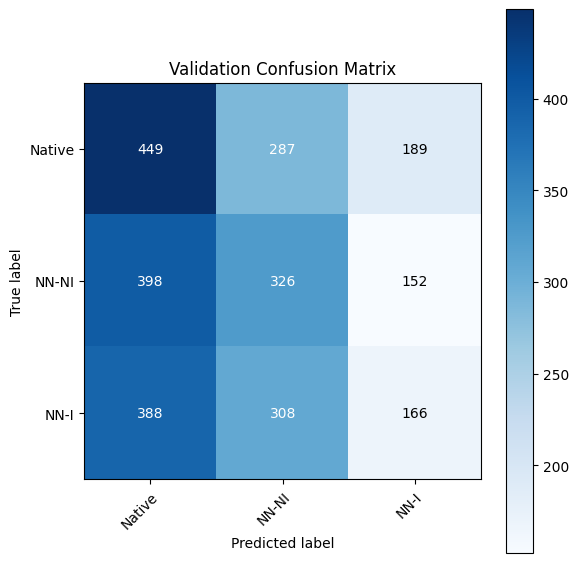


🔁 Epoch 2/10


Evaluating: 100%|██████████| 84/84 [00:02<00:00, 30.45it/s]


📉 Train Loss: 1.0983 | Accuracy: 0.3594
📈 Val Loss:   1.1028 | Accuracy: 0.3316

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.34      0.27      0.30       925
NN Non-Invasive       0.33      0.53      0.41       876
    NN Invasive       0.32      0.20      0.24       862

       accuracy                           0.33      2663
      macro avg       0.33      0.33      0.32      2663
   weighted avg       0.33      0.33      0.32      2663



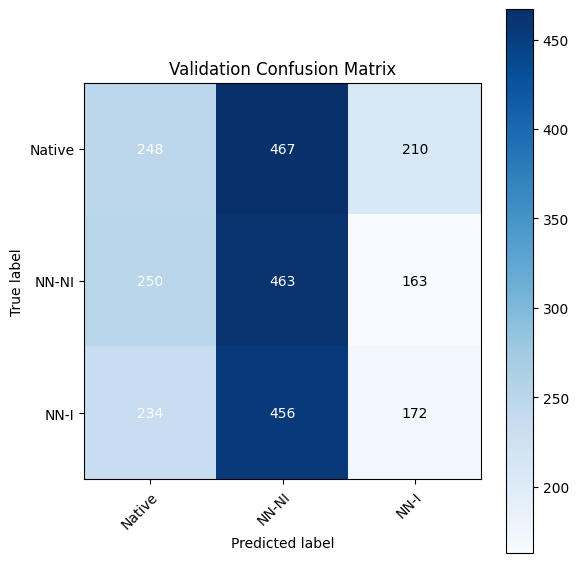


🔁 Epoch 3/10


Evaluating: 100%|██████████| 84/84 [00:02<00:00, 29.89it/s]


📉 Train Loss: 1.0938 | Accuracy: 0.3744
📈 Val Loss:   1.1078 | Accuracy: 0.3286

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.34      0.09      0.14       925
NN Non-Invasive       0.33      0.74      0.46       876
    NN Invasive       0.32      0.17      0.22       862

       accuracy                           0.33      2663
      macro avg       0.33      0.33      0.27      2663
   weighted avg       0.33      0.33      0.27      2663



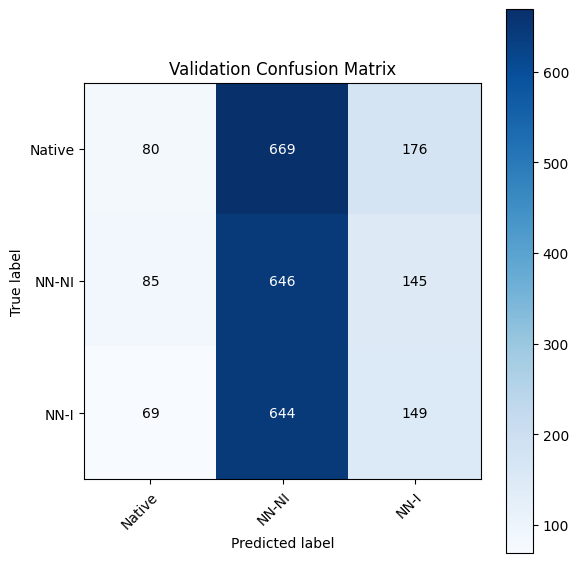


🔁 Epoch 4/10


Evaluating: 100%|██████████| 84/84 [00:02<00:00, 30.35it/s]


📉 Train Loss: 1.0889 | Accuracy: 0.3836
📈 Val Loss:   1.1043 | Accuracy: 0.3421

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.34      0.40      0.37       925
NN Non-Invasive       0.34      0.44      0.39       876
    NN Invasive       0.33      0.17      0.23       862

       accuracy                           0.34      2663
      macro avg       0.34      0.34      0.33      2663
   weighted avg       0.34      0.34      0.33      2663



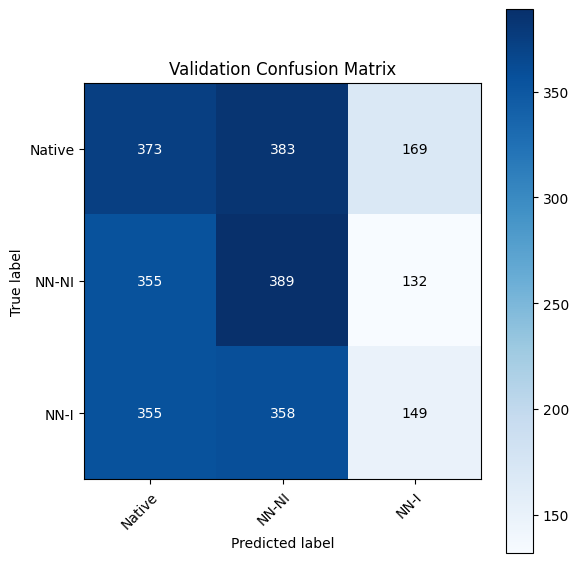


🔁 Epoch 5/10


Evaluating: 100%|██████████| 84/84 [00:02<00:00, 29.98it/s]


📉 Train Loss: 1.0838 | Accuracy: 0.4002
📈 Val Loss:   1.1104 | Accuracy: 0.3376

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.34      0.37      0.36       925
NN Non-Invasive       0.43      0.07      0.12       876
    NN Invasive       0.33      0.57      0.42       862

       accuracy                           0.34      2663
      macro avg       0.37      0.34      0.30      2663
   weighted avg       0.37      0.34      0.30      2663



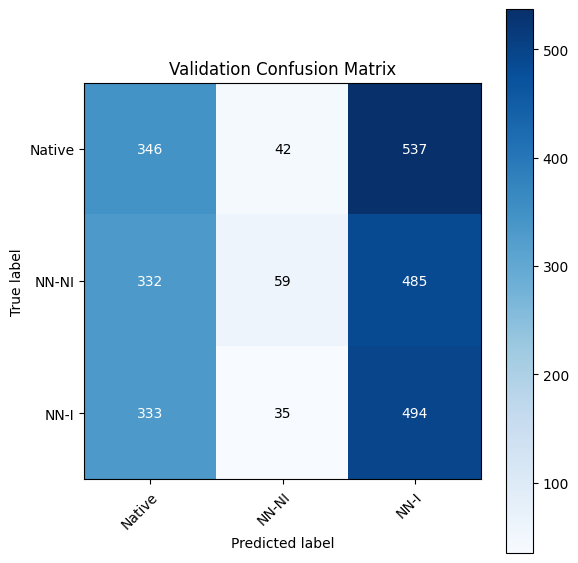


🔁 Epoch 6/10


Evaluating: 100%|██████████| 84/84 [00:02<00:00, 29.92it/s]


📉 Train Loss: 1.0807 | Accuracy: 0.3992
📈 Val Loss:   1.1162 | Accuracy: 0.3222

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.29      0.08      0.13       925
NN Non-Invasive       0.34      0.22      0.27       876
    NN Invasive       0.32      0.69      0.44       862

       accuracy                           0.32      2663
      macro avg       0.32      0.33      0.28      2663
   weighted avg       0.32      0.32      0.27      2663



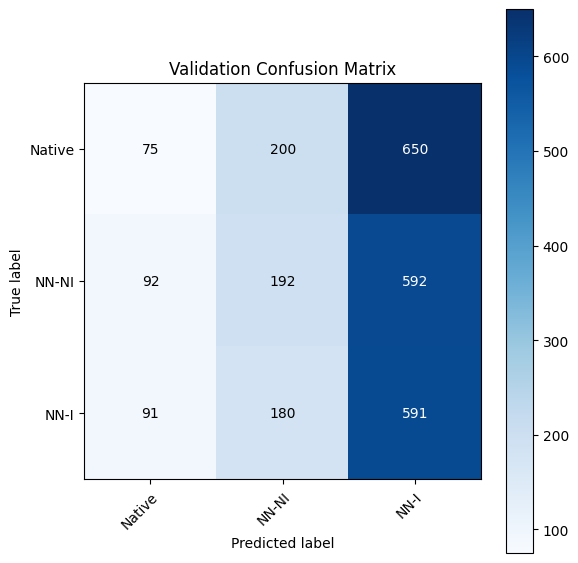


🔁 Epoch 7/10


Evaluating: 100%|██████████| 84/84 [00:02<00:00, 29.75it/s]


📉 Train Loss: 1.0757 | Accuracy: 0.4113
📈 Val Loss:   1.1077 | Accuracy: 0.3466

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.35      0.40      0.38       925
NN Non-Invasive       0.34      0.41      0.37       876
    NN Invasive       0.34      0.22      0.27       862

       accuracy                           0.35      2663
      macro avg       0.35      0.34      0.34      2663
   weighted avg       0.35      0.35      0.34      2663



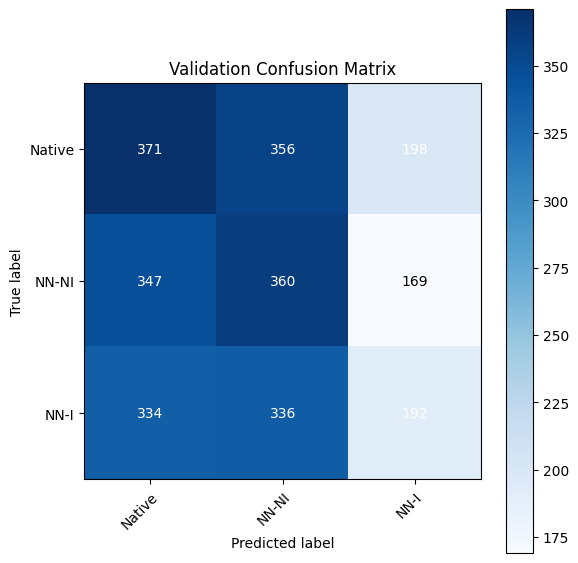


🔁 Epoch 8/10


Evaluating: 100%|██████████| 84/84 [00:02<00:00, 29.23it/s]


📉 Train Loss: 1.0713 | Accuracy: 0.4232
📈 Val Loss:   1.1088 | Accuracy: 0.3594

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.36      0.59      0.45       925
NN Non-Invasive       0.37      0.22      0.28       876
    NN Invasive       0.35      0.25      0.29       862

       accuracy                           0.36      2663
      macro avg       0.36      0.35      0.34      2663
   weighted avg       0.36      0.36      0.34      2663



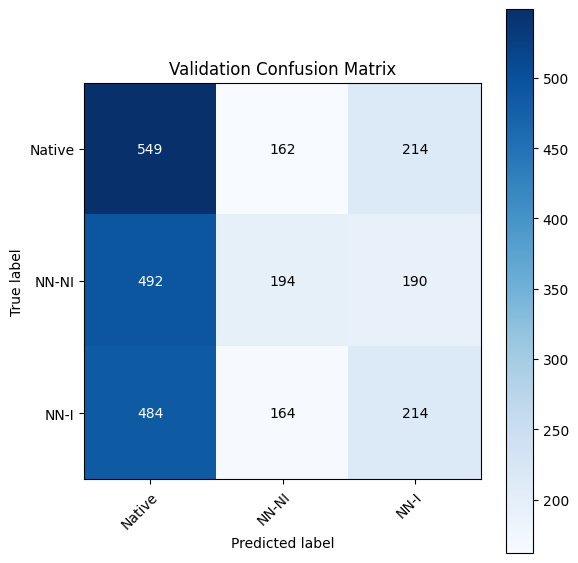


🔁 Epoch 9/10


Evaluating: 100%|██████████| 84/84 [00:02<00:00, 28.96it/s]


📉 Train Loss: 1.0655 | Accuracy: 0.4339
📈 Val Loss:   1.1117 | Accuracy: 0.3500

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.36      0.53      0.43       925
NN Non-Invasive       0.35      0.33      0.34       876
    NN Invasive       0.34      0.18      0.23       862

       accuracy                           0.35      2663
      macro avg       0.35      0.35      0.33      2663
   weighted avg       0.35      0.35      0.33      2663



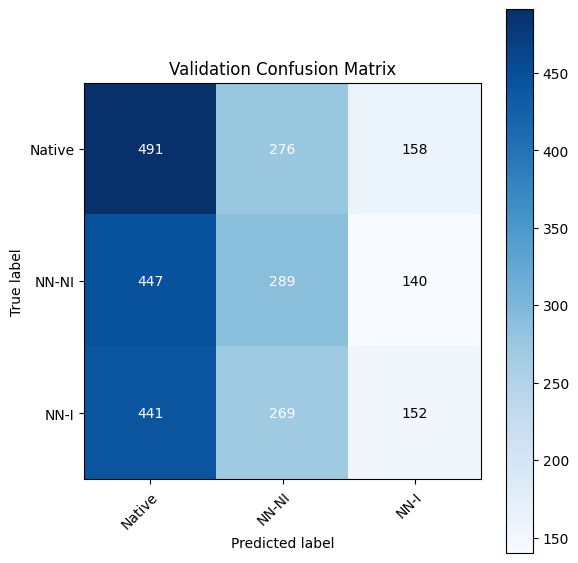


🔁 Epoch 10/10


Evaluating: 100%|██████████| 84/84 [00:02<00:00, 29.90it/s]


📉 Train Loss: 1.0601 | Accuracy: 0.4447
📈 Val Loss:   1.1240 | Accuracy: 0.3316

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.34      0.18      0.23       925
NN Non-Invasive       0.34      0.61      0.43       876
    NN Invasive       0.31      0.22      0.25       862

       accuracy                           0.33      2663
      macro avg       0.33      0.33      0.31      2663
   weighted avg       0.33      0.33      0.31      2663



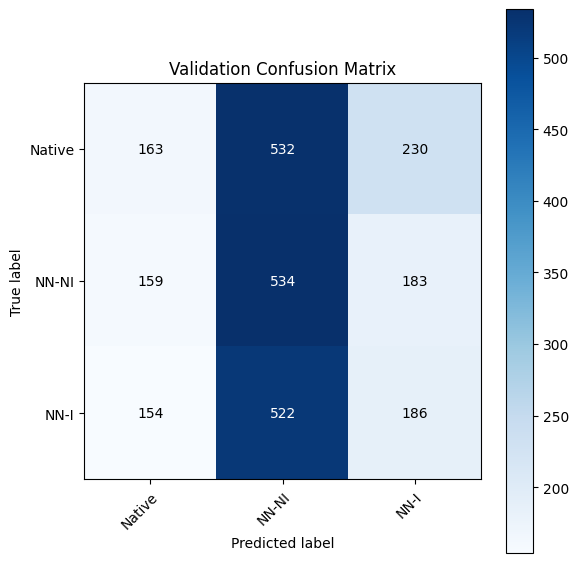

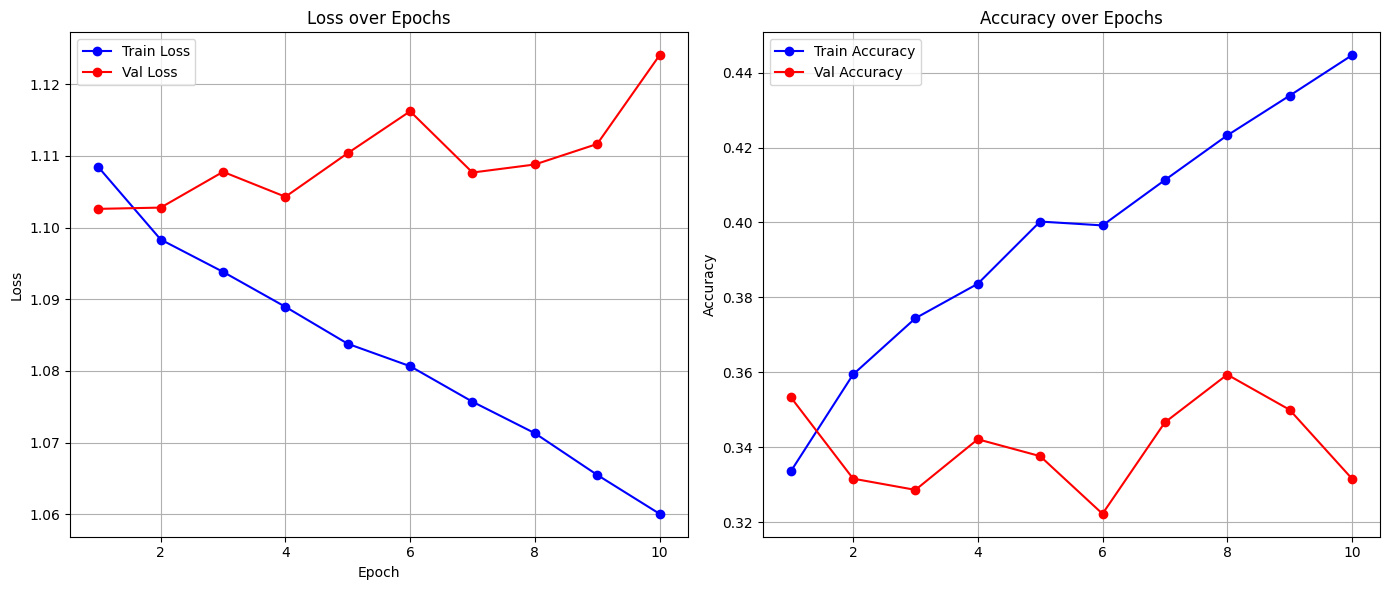

Total execution time: 273.87 seconds


In [10]:
create_model_and_predict(folder_name="taxas", use_bioclip=False, output_dir="invasive_species", model_name="prova")

Using device: cuda
BioCLIP 2!


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(



🔁 Epoch 1/10


Evaluating: 100%|██████████| 84/84 [01:55<00:00,  1.37s/it]


📉 Train Loss: 1.1137 | Accuracy: 0.3339
📈 Val Loss:   1.1037 | Accuracy: 0.3282

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.33      0.35      0.34       926
NN Non-Invasive       0.33      0.51      0.40       884
    NN Invasive       0.32      0.12      0.18       853

       accuracy                           0.33      2663
      macro avg       0.33      0.33      0.30      2663
   weighted avg       0.33      0.33      0.31      2663



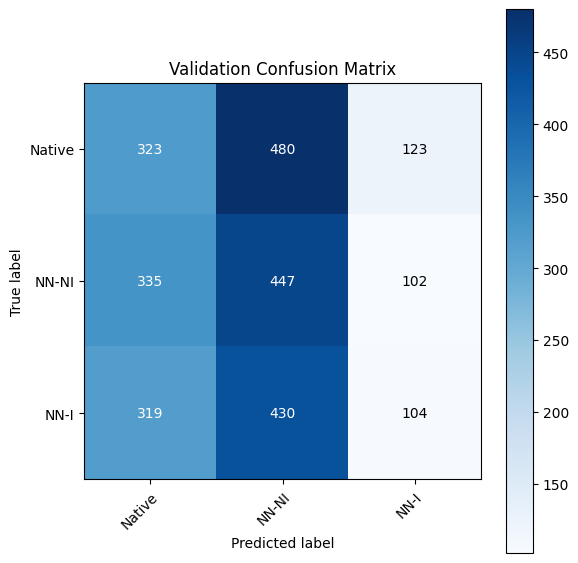


🔁 Epoch 2/10


Evaluating: 100%|██████████| 84/84 [01:55<00:00,  1.37s/it]

📉 Train Loss: 1.1012 | Accuracy: 0.3571
📈 Val Loss:   1.1172 | Accuracy: 0.3233

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.29      0.03      0.05       926
NN Non-Invasive       0.37      0.10      0.16       884
    NN Invasive       0.32      0.87      0.47       853

       accuracy                           0.32      2663
      macro avg       0.32      0.33      0.23      2663
   weighted avg       0.32      0.32      0.22      2663



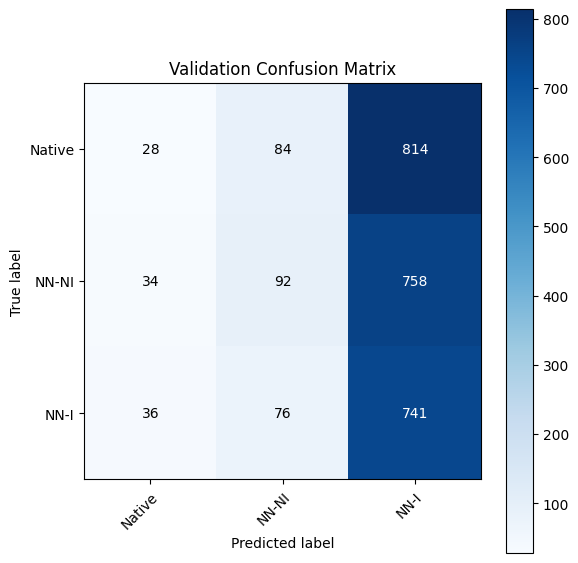


🔁 Epoch 3/10


Evaluating: 100%|██████████| 84/84 [01:55<00:00,  1.37s/it]


📉 Train Loss: 1.0953 | Accuracy: 0.3658
📈 Val Loss:   1.1118 | Accuracy: 0.3372

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.34      0.12      0.18       926
NN Non-Invasive       0.34      0.74      0.46       884
    NN Invasive       0.33      0.15      0.21       853

       accuracy                           0.34      2663
      macro avg       0.34      0.34      0.28      2663
   weighted avg       0.34      0.34      0.28      2663



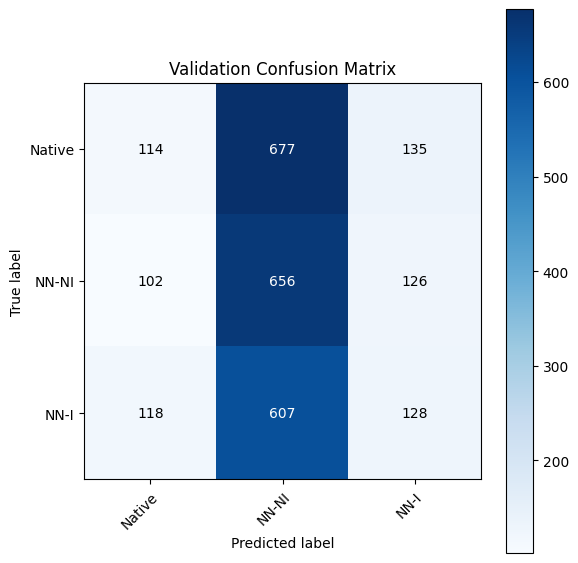


🔁 Epoch 4/10


Evaluating: 100%|██████████| 84/84 [01:55<00:00,  1.37s/it]


📉 Train Loss: 1.0916 | Accuracy: 0.3722
📈 Val Loss:   1.1072 | Accuracy: 0.3305

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.32      0.28      0.30       926
NN Non-Invasive       0.33      0.42      0.37       884
    NN Invasive       0.34      0.29      0.31       853

       accuracy                           0.33      2663
      macro avg       0.33      0.33      0.33      2663
   weighted avg       0.33      0.33      0.33      2663



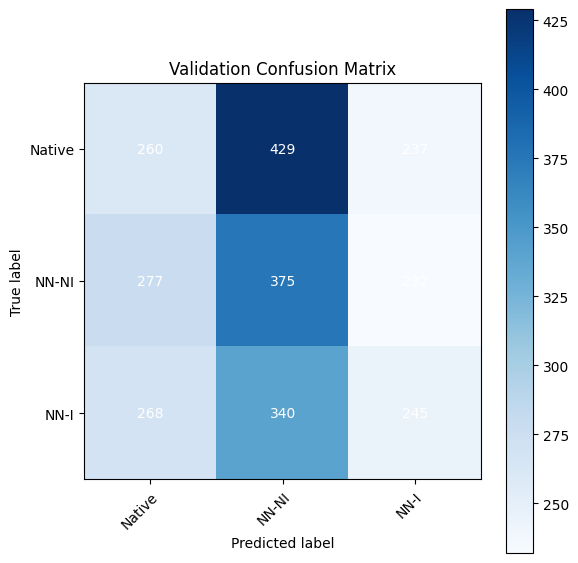


🔁 Epoch 5/10


Evaluating: 100%|██████████| 84/84 [01:55<00:00,  1.37s/it]

📉 Train Loss: 1.0864 | Accuracy: 0.3893
📈 Val Loss:   1.1097 | Accuracy: 0.3402

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.35      0.76      0.48       926
NN Non-Invasive       0.31      0.10      0.15       884
    NN Invasive       0.32      0.13      0.19       853

       accuracy                           0.34      2663
      macro avg       0.33      0.33      0.27      2663
   weighted avg       0.33      0.34      0.28      2663



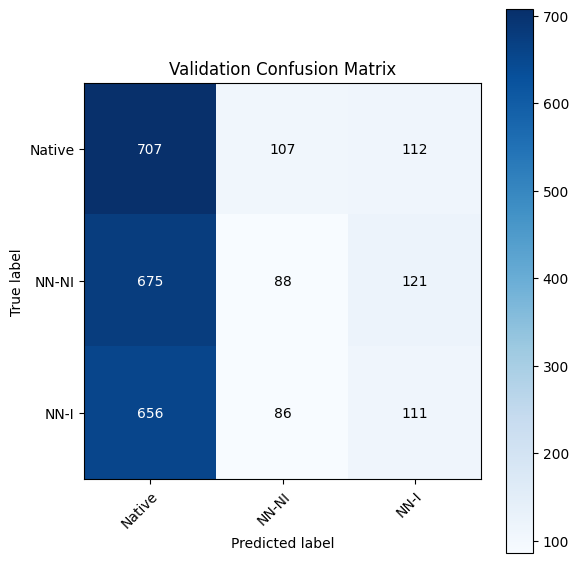


🔁 Epoch 6/10


Evaluating: 100%|██████████| 84/84 [01:54<00:00,  1.37s/it]

📉 Train Loss: 1.0827 | Accuracy: 0.3878
📈 Val Loss:   1.1150 | Accuracy: 0.3395

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.35      0.78      0.48       926
NN Non-Invasive       0.34      0.05      0.09       884
    NN Invasive       0.31      0.16      0.21       853

       accuracy                           0.34      2663
      macro avg       0.33      0.33      0.26      2663
   weighted avg       0.33      0.34      0.26      2663



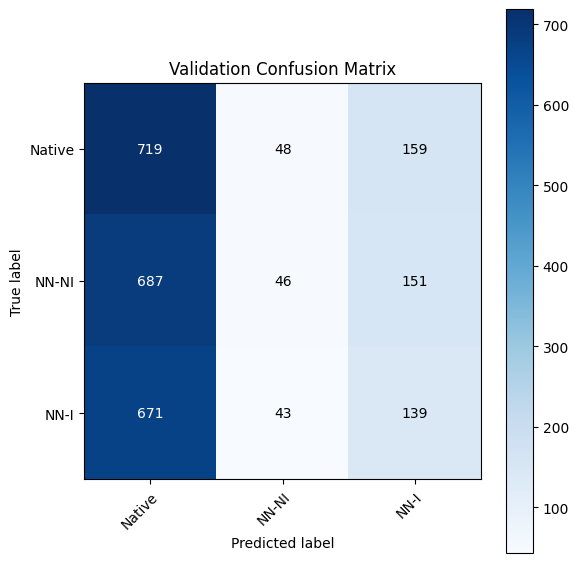


🔁 Epoch 7/10


Evaluating: 100%|██████████| 84/84 [01:55<00:00,  1.37s/it]

📉 Train Loss: 1.0772 | Accuracy: 0.4044
📈 Val Loss:   1.1159 | Accuracy: 0.3425

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.35      0.88      0.50       926
NN Non-Invasive       0.33      0.07      0.12       884
    NN Invasive       0.31      0.04      0.07       853

       accuracy                           0.34      2663
      macro avg       0.33      0.33      0.23      2663
   weighted avg       0.33      0.34      0.24      2663



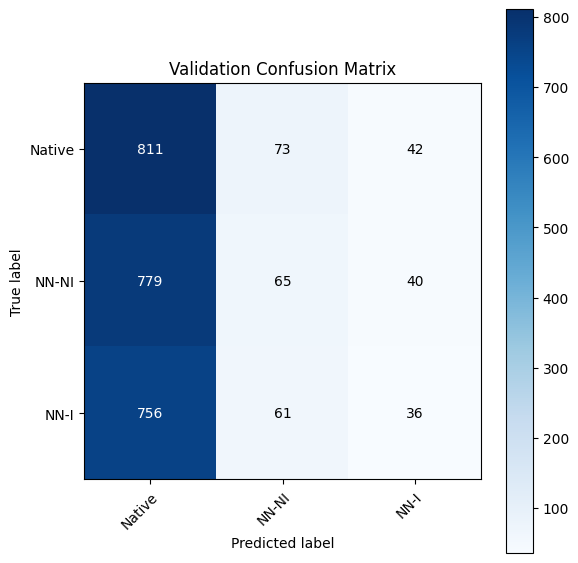


🔁 Epoch 8/10


Evaluating: 100%|██████████| 84/84 [01:55<00:00,  1.37s/it]


📉 Train Loss: 1.0725 | Accuracy: 0.4160
📈 Val Loss:   1.1387 | Accuracy: 0.3211

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.34      0.18      0.24       926
NN Non-Invasive       0.31      0.02      0.04       884
    NN Invasive       0.32      0.79      0.45       853

       accuracy                           0.32      2663
      macro avg       0.32      0.33      0.24      2663
   weighted avg       0.32      0.32      0.24      2663



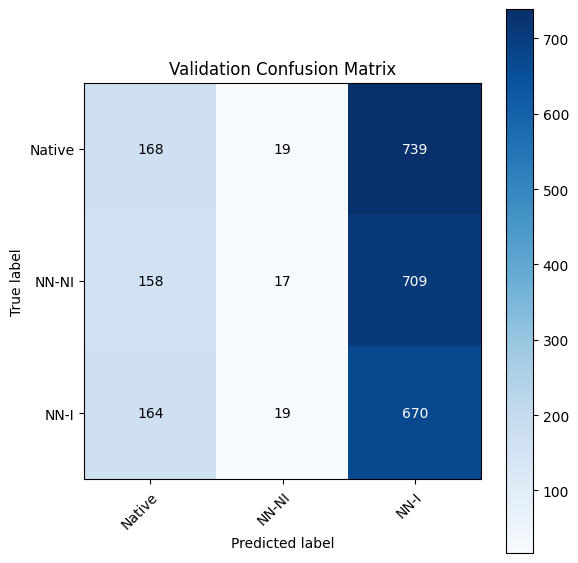


🔁 Epoch 9/10


Evaluating: 100%|██████████| 84/84 [01:55<00:00,  1.37s/it]

📉 Train Loss: 1.0668 | Accuracy: 0.4157
📈 Val Loss:   1.1188 | Accuracy: 0.3241

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.35      0.22      0.27       926
NN Non-Invasive       0.33      0.29      0.31       884
    NN Invasive       0.31      0.48      0.38       853

       accuracy                           0.32      2663
      macro avg       0.33      0.33      0.32      2663
   weighted avg       0.33      0.32      0.32      2663



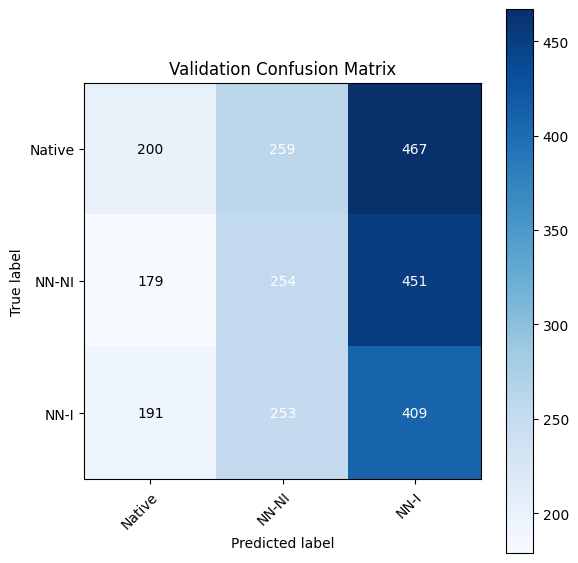


🔁 Epoch 10/10


Evaluating: 100%|██████████| 84/84 [01:55<00:00,  1.37s/it]

📉 Train Loss: 1.0614 | Accuracy: 0.4262
📈 Val Loss:   1.1197 | Accuracy: 0.3346

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.34      0.33      0.33       926
NN Non-Invasive       0.34      0.53      0.41       884
    NN Invasive       0.32      0.14      0.20       853

       accuracy                           0.33      2663
      macro avg       0.33      0.33      0.31      2663
   weighted avg       0.33      0.33      0.31      2663



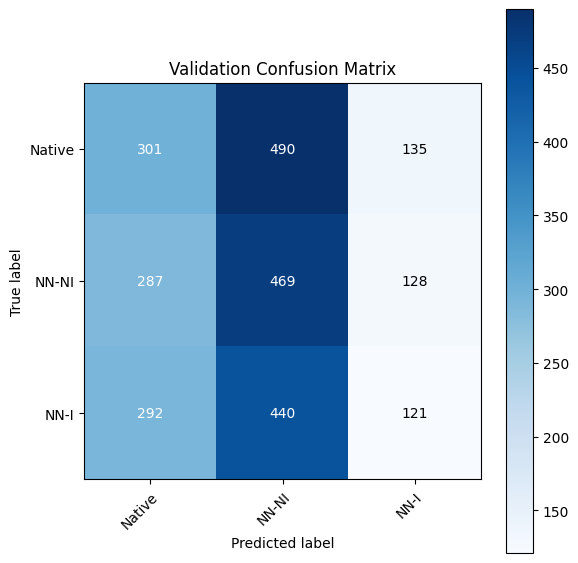

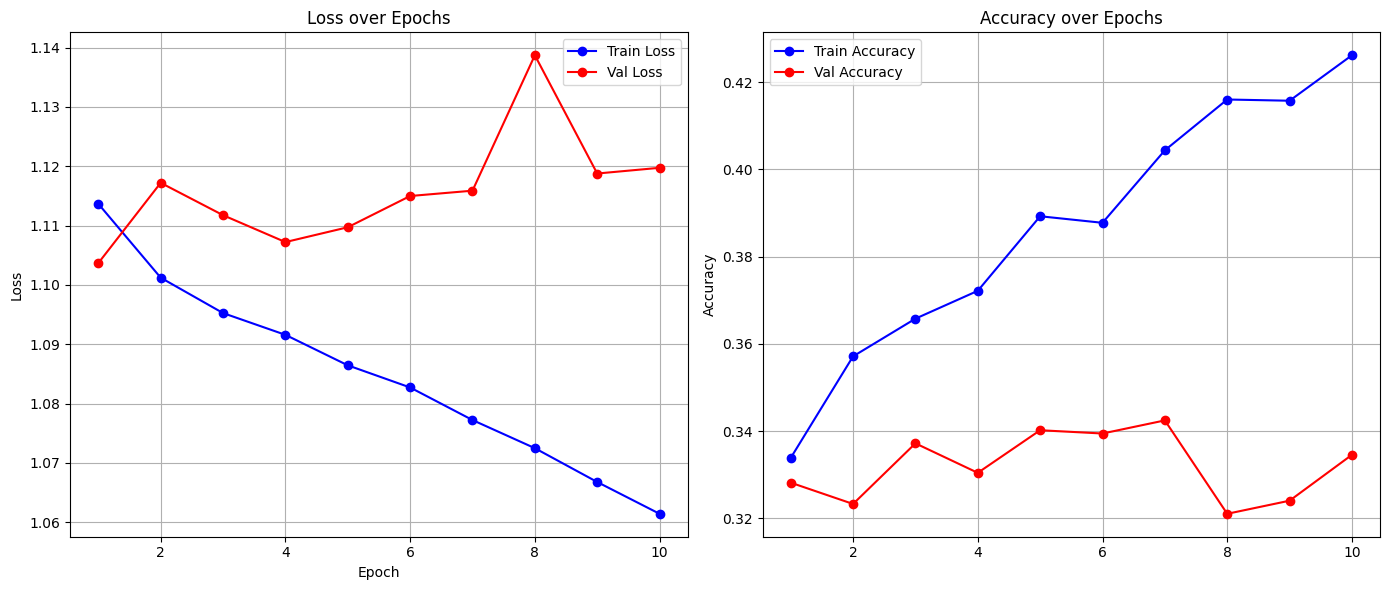

Total execution time: 7244.46 seconds


In [10]:
create_model_and_predict(folder_name="taxas", use_bioclip=True, bioclip_version=2, output_dir="invasive_species", model_name="prova")

Using device: cuda


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(



🔁 Epoch 1/10


Evaluating: 100%|██████████| 84/84 [00:29<00:00,  2.80it/s]


📉 Train Loss: 1.1020 | Accuracy: 0.3273
📈 Val Loss:   1.1015 | Accuracy: 0.3413

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.35      0.64      0.45       921
NN Non-Invasive       0.38      0.02      0.05       903
    NN Invasive       0.32      0.36      0.34       839

       accuracy                           0.34      2663
      macro avg       0.35      0.34      0.28      2663
   weighted avg       0.35      0.34      0.28      2663



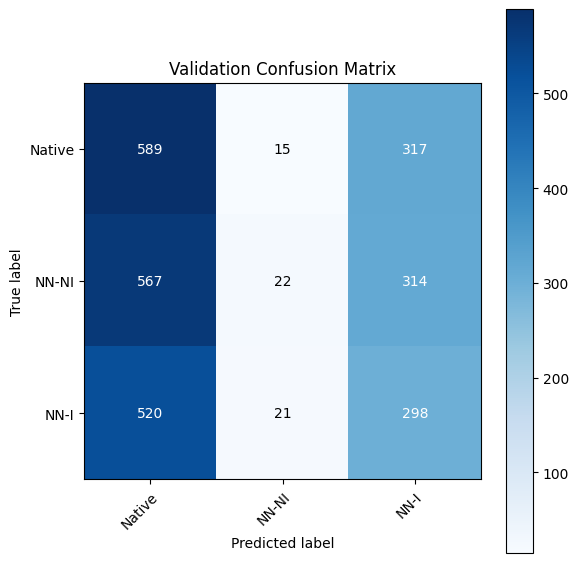


🔁 Epoch 2/10


Evaluating: 100%|██████████| 84/84 [00:29<00:00,  2.83it/s]


📉 Train Loss: 1.0952 | Accuracy: 0.3653
📈 Val Loss:   1.1035 | Accuracy: 0.3387

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.36      0.36      0.36       921
NN Non-Invasive       0.40      0.06      0.11       903
    NN Invasive       0.32      0.61      0.42       839

       accuracy                           0.34      2663
      macro avg       0.36      0.34      0.30      2663
   weighted avg       0.36      0.34      0.29      2663



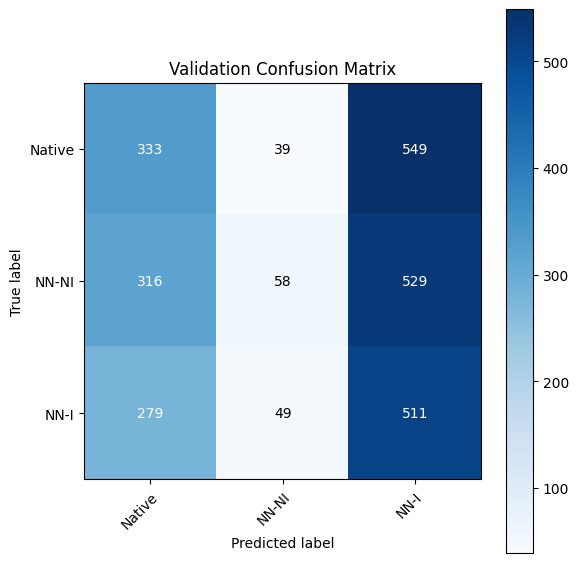


🔁 Epoch 3/10


Evaluating: 100%|██████████| 84/84 [00:29<00:00,  2.83it/s]


📉 Train Loss: 1.0895 | Accuracy: 0.3863
📈 Val Loss:   1.1017 | Accuracy: 0.3481

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.35      0.76      0.48       921
NN Non-Invasive       0.33      0.12      0.17       903
    NN Invasive       0.33      0.14      0.20       839

       accuracy                           0.35      2663
      macro avg       0.34      0.34      0.29      2663
   weighted avg       0.34      0.35      0.29      2663



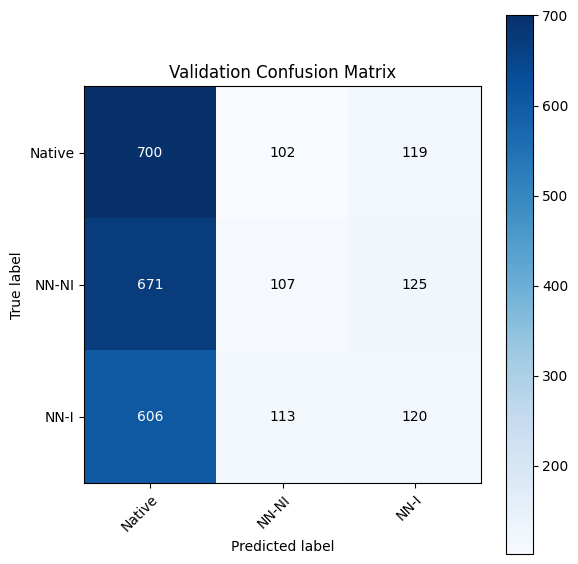


🔁 Epoch 4/10


Evaluating: 100%|██████████| 84/84 [00:29<00:00,  2.82it/s]


📉 Train Loss: 1.0846 | Accuracy: 0.4029
📈 Val Loss:   1.1028 | Accuracy: 0.3395

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.35      0.45      0.39       921
NN Non-Invasive       0.34      0.22      0.27       903
    NN Invasive       0.32      0.35      0.34       839

       accuracy                           0.34      2663
      macro avg       0.34      0.34      0.33      2663
   weighted avg       0.34      0.34      0.33      2663



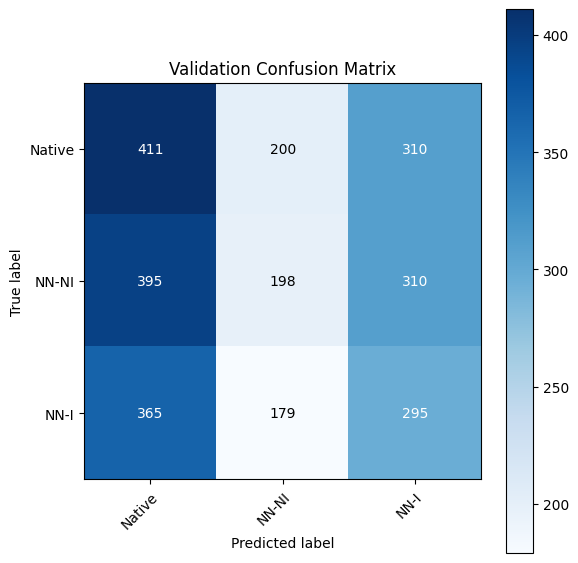


🔁 Epoch 5/10


Evaluating: 100%|██████████| 84/84 [00:29<00:00,  2.83it/s]


📉 Train Loss: 1.0786 | Accuracy: 0.4119
📈 Val Loss:   1.1047 | Accuracy: 0.3387

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.35      0.60      0.44       921
NN Non-Invasive       0.33      0.12      0.18       903
    NN Invasive       0.31      0.29      0.30       839

       accuracy                           0.34      2663
      macro avg       0.33      0.34      0.31      2663
   weighted avg       0.33      0.34      0.31      2663



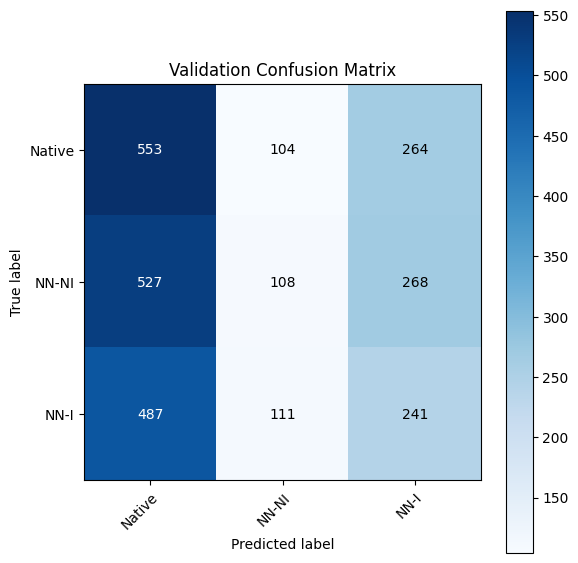


🔁 Epoch 6/10


Evaluating: 100%|██████████| 84/84 [00:29<00:00,  2.83it/s]


📉 Train Loss: 1.0725 | Accuracy: 0.4234
📈 Val Loss:   1.1102 | Accuracy: 0.3293

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.35      0.33      0.34       921
NN Non-Invasive       0.34      0.12      0.17       903
    NN Invasive       0.31      0.56      0.40       839

       accuracy                           0.33      2663
      macro avg       0.34      0.33      0.30      2663
   weighted avg       0.34      0.33      0.30      2663



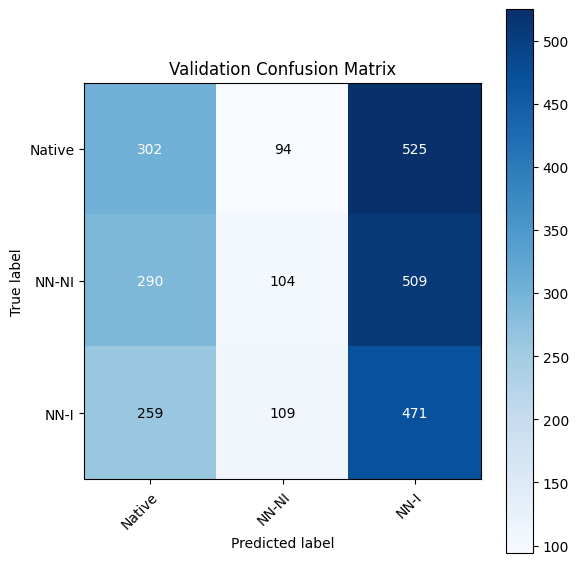


🔁 Epoch 7/10


Evaluating: 100%|██████████| 84/84 [00:29<00:00,  2.83it/s]


📉 Train Loss: 1.0660 | Accuracy: 0.4430
📈 Val Loss:   1.1085 | Accuracy: 0.3353

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.35      0.41      0.38       921
NN Non-Invasive       0.33      0.22      0.26       903
    NN Invasive       0.32      0.38      0.35       839

       accuracy                           0.34      2663
      macro avg       0.33      0.34      0.33      2663
   weighted avg       0.33      0.34      0.33      2663



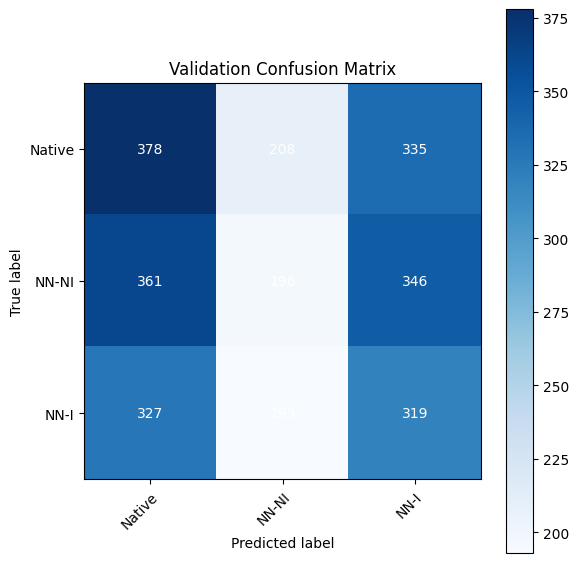


🔁 Epoch 8/10


Evaluating: 100%|██████████| 84/84 [00:29<00:00,  2.83it/s]


📉 Train Loss: 1.0580 | Accuracy: 0.4503
📈 Val Loss:   1.1120 | Accuracy: 0.3316

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.35      0.39      0.37       921
NN Non-Invasive       0.32      0.27      0.29       903
    NN Invasive       0.32      0.34      0.33       839

       accuracy                           0.33      2663
      macro avg       0.33      0.33      0.33      2663
   weighted avg       0.33      0.33      0.33      2663



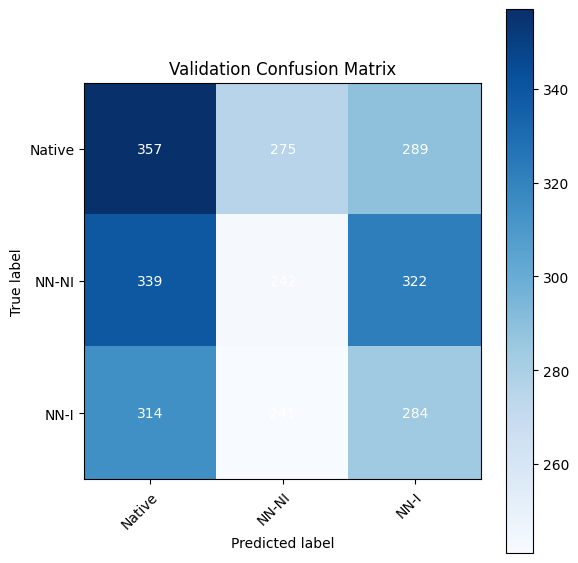


🔁 Epoch 9/10


Evaluating: 100%|██████████| 84/84 [00:29<00:00,  2.82it/s]


📉 Train Loss: 1.0500 | Accuracy: 0.4754
📈 Val Loss:   1.1148 | Accuracy: 0.3248

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.35      0.32      0.33       921
NN Non-Invasive       0.31      0.25      0.28       903
    NN Invasive       0.32      0.41      0.36       839

       accuracy                           0.32      2663
      macro avg       0.33      0.33      0.32      2663
   weighted avg       0.33      0.32      0.32      2663



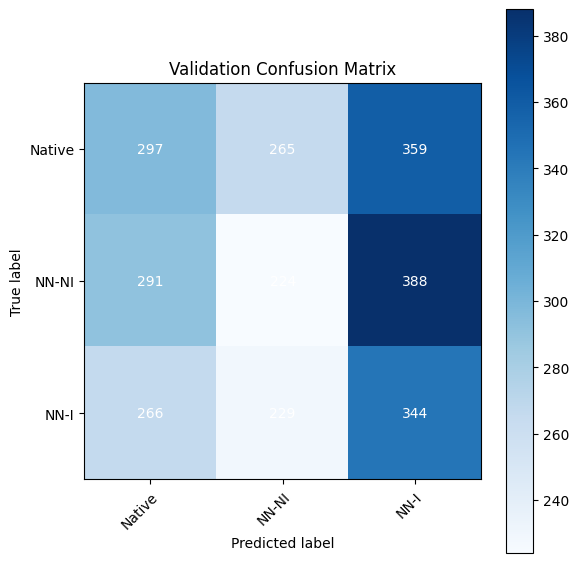


🔁 Epoch 10/10


Evaluating: 100%|██████████| 84/84 [00:29<00:00,  2.82it/s]


📉 Train Loss: 1.0413 | Accuracy: 0.4814
📈 Val Loss:   1.1156 | Accuracy: 0.3308

📋 Classification Report:
                 precision    recall  f1-score   support

         Native       0.34      0.56      0.42       921
NN Non-Invasive       0.31      0.26      0.28       903
    NN Invasive       0.32      0.15      0.21       839

       accuracy                           0.33      2663
      macro avg       0.33      0.33      0.31      2663
   weighted avg       0.33      0.33      0.31      2663



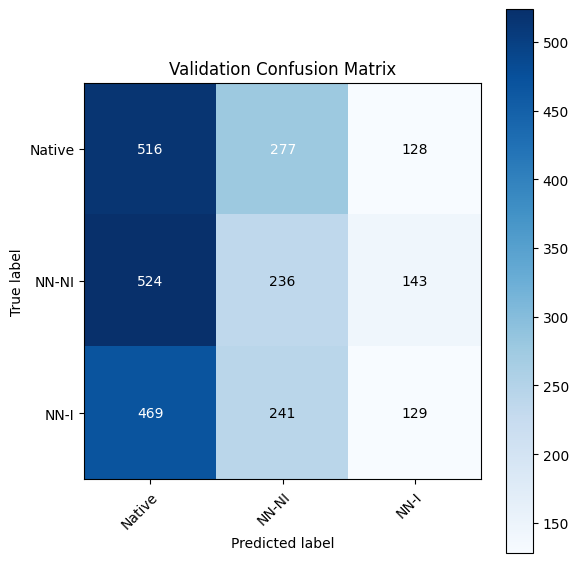

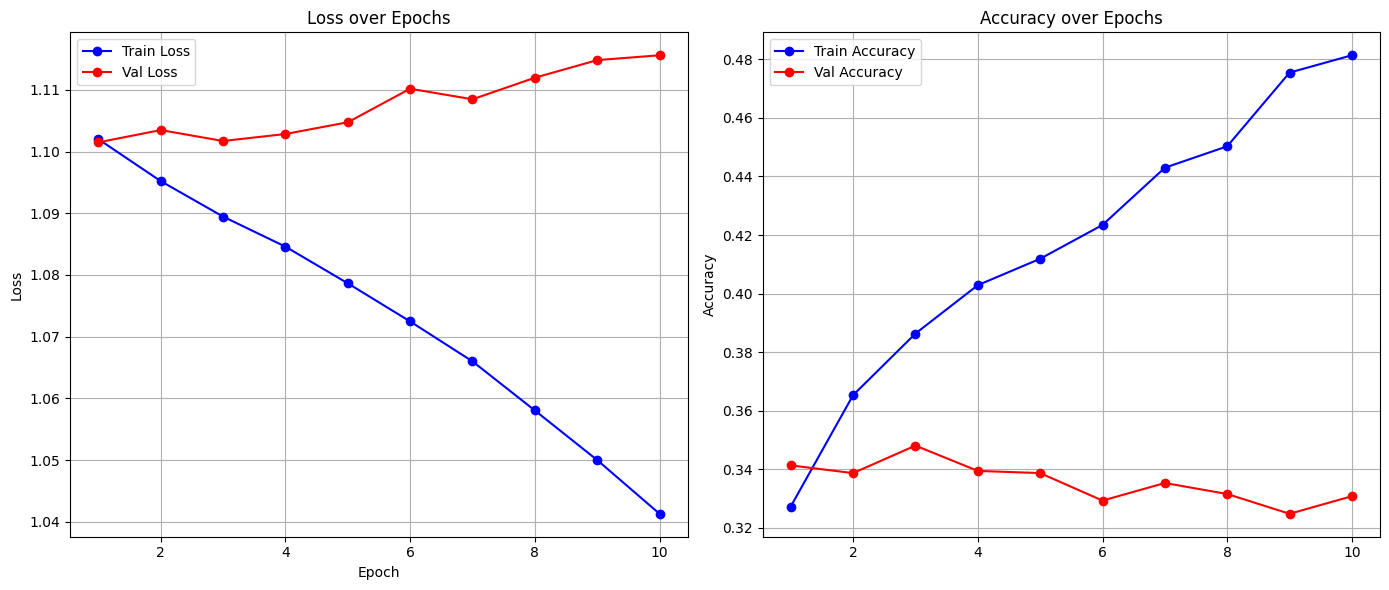

Total execution time: 1923.60 seconds


In [9]:
create_model_and_predict(folder_name="taxas", use_bioclip=True, output_dir="invasive_species", model_name="prova")